## Simple linear regression

## 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

## 2. READ & LOAD CSV FILE

In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


## 3. FEATURE AND TARGET VARIABLES ASSIGN

In [4]:
x = dataset[["area_sqft"]]
y = dataset["house_price_inr"]

## 4. TRAING & TESTING SPILTING RECORDS

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2)

## [A] TRAING SIZE

In [6]:
len(x_train)

3360

## [B] TESTING SIZE

In [7]:
len(x_test)

840

## 5. CREATE LINEAR REGRESSION MODEL

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. PREDICT NEW house_price_inr FROM THE x_test

In [10]:
prdict = lr.predict(x_test)
prdict.astype(int)

array([15063011, 33522043, 24041530, 31012073, 30323625, 13241490,
       25102888, 28674216, 23654277, 38800150, 29563463,  8924342,
       19882152, 23926788, 37251140, 27770627, 29147525, 33407301,
       14489303, 28616845, 19968208, 26522814, 28903699, 13442287,
       10043072, 15980942,  8264579, 27555487, 21172993, 29190553,
       26322016, 29377008, 14919584, 22320408, 27670228, 22019212,
       17214413, 13298861,  8264579, 21890127, 27311661, 34425632,
       23754676, 12223159, 26408072, 17013615, 19078962, 38800150,
        8264579, 38097359, 35099738, 26996122, 18333142, 22019212,
       32145145, 29276609, 33694155, 23955474, 20785741, 29147525,
       18017603, 25733966, 33479015, 22564233, 22363436, 23955474,
       27010465, 29907687, 20441516, 32202516, 27426403, 22765031,
        8264579, 22779374, 20943510, 15536319, 12151446, 33063077,
       18648681, 34239177, 23926788,  8264579, 31198528, 31356298,
       38427240, 32216859, 29879002, 28745930, 27512459, 23941

In [11]:
result = x_test.copy()
result["accual house_price"] = y_test.values
result["New house_price"] = prdict.astype(int)
print(result)

      area_sqft  accual house_price  New house_price
3511  -0.983998          17140187.0         15063011
715    1.197628          18067821.0         33522043
550    0.077150          31395326.0         24041530
786    0.900981          26242299.0         31012073
3091   0.819615          29849715.0         30323625
...         ...                 ...              ...
3609  -0.475460          27685274.0         19365815
685    0.767066          11636059.0         29879002
1955   1.495970          41939396.0         36046355
236   -1.787487          11103961.0          8264579
3360  -1.289120          11619422.0         12481328

[840 rows x 3 columns]


## 7. Draw Linear Regression Graph

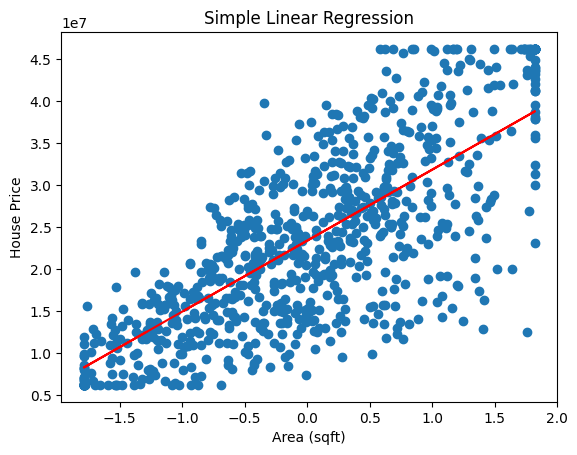

In [12]:
# ==================================================
# PLOT REGRESSION GRAPH
# ==================================================

plt.scatter(x_test, y_test)

# regression line in red
plt.plot(x_test, prdict, color="red")

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")

plt.title("Simple Linear Regression")

plt.show()

Simple Linear Regression: Area vs House Price

This graph illustrates the relationship between house area (in square feet) and house price using a Simple Linear Regression model. The scatter points represent the actual observations from the dataset, while the straight line represents the regression line predicted by the model.

## 8. slope & intercept

In [13]:
slope = lr.coef_
print(f"slope : {slope.astype(int)}")

slope : [8461135]


In [14]:
intercept = lr.intercept_
print(f"Intercept : {intercept.astype(int)}")

Intercept : 23388750


## 9. Validate Linear Regression Assumptions

## [A] Linearity

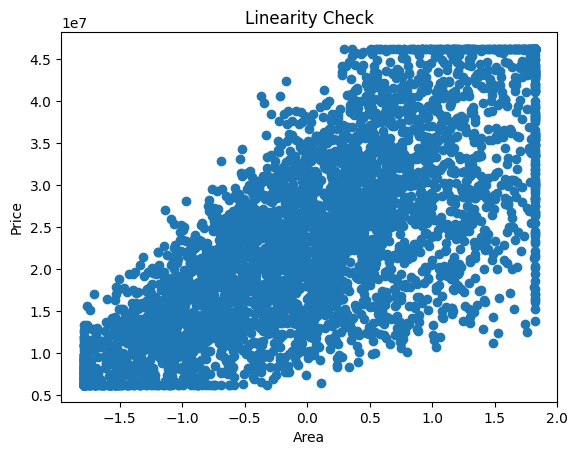

In [15]:
plt.scatter(dataset["area_sqft"], dataset["house_price_inr"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linearity Check")
plt.show()

Linearity Assumption Check (Area vs House Price)

This scatter plot is used to verify the linearity assumption of the Linear Regression model. The linearity assumption states that the independent variable and the dependent variable should have a linear relationship.

## [B] Homoscedasticity

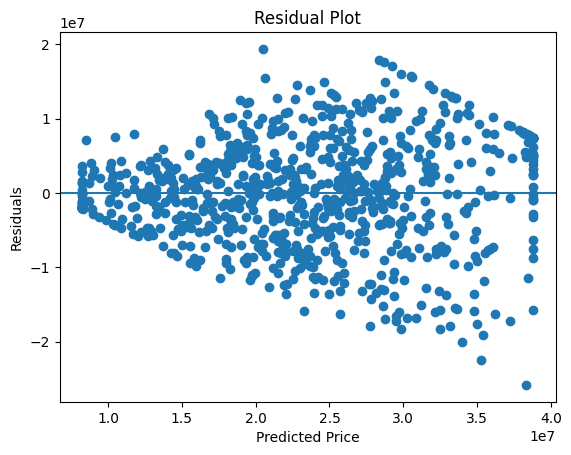

In [16]:
residuals = y_test - prdict

plt.scatter(prdict, residuals)

plt.axhline(0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

Residual Plot Analysis

This residual plot is used to evaluate the performance and assumptions of the Linear Regression model. Residuals represent the difference between the actual house prices and the predicted house prices generated by the regression model.

## [C] Normal Distribution of Residuals

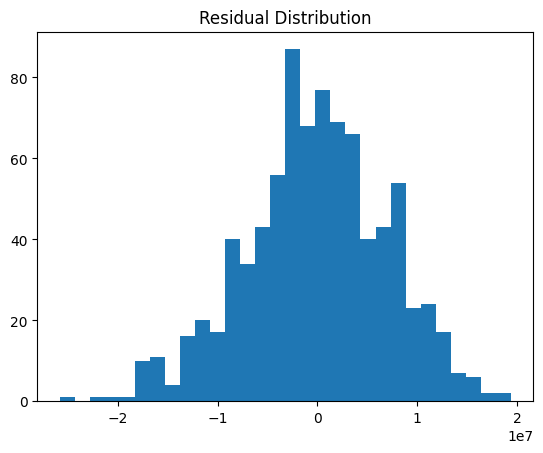

In [17]:
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")

plt.show()

This write-up acts as an excellent transition between your Simple Linear Regression phase and your Multiple Linear Regression phase. By pointing out that the Area only explains 57.1% of the price, it perfectly justifies why you need to add more variables (like bedrooms and location) to get a more accurate model!

## 10. Calculate Evaluation Metrics

## [A] Mean squared error

In [18]:
mse = mean_squared_error(y_test,prdict)
print(f"Mean squared error : {mse}")

Mean squared error : 50026044975414.92


Mean Squared Error (MSE) calculates the average of squared errors, giving more importance to larger errors. 

## [B] Mean absolute error

In [19]:
mae = mean_absolute_error(y_test,prdict)
print(f"Mean absolute error : {mae}")

Mean absolute error : 5566292.548441067


Mean Absolute Error (MAE) measures the average absolute difference between the actual and predicted values.

## [C] Root mean sqaured error

In [20]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 7072909.229971421


 Root Mean Squared Error (RMSE) is the square root of MSE and provides error values in the same units as the target variable.

## [D] R2 Score

In [21]:
r2 = r2_score(y_test,prdict)
print(f"R2 score : {r2}")

R2 score : 0.6011223954791616


The R² Score indicates the proportion of variance in the target variable that is explained by the model. Adju

In [22]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 60.11223954791616%


## [E] Adjusted r2 score

In [23]:
# Number of samples and predictors
n = len(y_test)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.6006464078842679


Adjusted R² Score further adjusts the R² value based on the number of predictors used in the model.


## 11. Conclusion of Simple Linear Regression

The Simple Linear Regression model was developed to analyze the relationship between house area (sqft) and house price (INR). The model attempts to predict house prices using the linear relationship.For prediction house price.The useful things is all the features required not only single features.So actual the prediction comes from the multiple linear regression with using multiple features or variables.